# Módulo 6 — Opciones americanas por Longstaff-Schwartz

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas
**Autor:** Jorge Rodríguez Lázaro
**Última actualización:** 2026-09-26

---

## Objetivo del módulo

Todas las opciones que hemos valorado hasta ahora eran **europeas**: solo se ejercen en el vencimiento. Este módulo aborda las **americanas**, que pueden ejercerse en *cualquier* momento hasta el vencimiento. Ese pequeño cambio en las reglas convierte la valoración en un **problema de parada óptima**, mucho más difícil, y es donde el Monte Carlo se enfrenta a su reto más famoso.

La dificultad: en un instante dado hay que decidir *ejercer ahora o seguir esperando*, y para eso hace falta el **valor de continuación** — el valor esperado de seguir con la opción viva —, que depende del futuro. Simular hacia delante no lo da directamente. La solución, el algoritmo de **Longstaff-Schwartz (2001)**, es una de las ideas más elegantes de las finanzas computacionales: **estimar el valor de continuación por regresión** sobre las propias trayectorias simuladas. Combina simulación, regresión estadística y programación dinámica — justo la intersección de la estadística y la computación.

## Estructura

| Sección | Tema | Idea clave |
|---------|------|------------|
| 1 | El problema de la parada óptima | Por qué las americanas no tienen fórmula y por qué MC "normal" no basta. |
| 2 | El algoritmo de Longstaff-Schwartz | Regresión para estimar el valor de continuación, hacia atrás en el tiempo. |
| 3 | Implementación y validación | Contraste contra un árbol binomial; prima de ejercicio anticipado. |
| 4 | La frontera de ejercicio y análisis | Cuándo conviene ejercer; sesgos y límites del método. |

## Referencias

- Longstaff, F. & Schwartz, E. (2001). *Valuing American Options by Simulation: A Simple Least-Squares Approach*. Review of Financial Studies, 14(1).
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 8.
- Cox, Ross & Rubinstein (1979). *Option Pricing: A Simplified Approach*. J. Financial Economics.

> **Nota sobre el código.** Reutiliza `mcquant.simular_gbm` y `black_scholes`; el algoritmo LSM y el árbol binomial de referencia se implementan *inline*.

---

# Sección 1 — El problema de la parada óptima

## 1.1 Qué cambia con el ejercicio anticipado

Una opción **americana** puede ejercerse en cualquier instante $t \le T$. Su poseedor se enfrenta continuamente a una decisión: **ejercer ahora** y cobrar el payoff inmediato, o **esperar** con la esperanza de algo mejor. El valor de la opción es el de la **estrategia de ejercicio óptima**:

$$
V_0 = \sup_{\tau \le T} \mathbb{E}^{\mathbb{Q}}\!\left[e^{-r\tau}\,\text{payoff}(S_\tau)\right]
$$

donde $\tau$ es un *tiempo de parada* (una regla que decide cuándo ejercer usando solo información hasta ese momento). El supremo sobre todas las estrategias posibles es lo que hace esto difícil: no es una simple esperanza, es un problema de **optimización sobre estrategias**.

Nos centramos en una **put americana**, porque es el caso interesante: una call americana sobre un activo sin dividendos vale *exactamente igual* que la europea (nunca conviene ejercer antes), mientras que una put americana **sí** tiene valor de ejercicio anticipado — si el precio cae mucho, conviene cobrar $K - S_t$ ya y no arriesgarse a que rebote.

## 1.2 Por qué el Monte Carlo estándar no basta

Simular trayectorias hacia delante da el precio final de cada una, pero la decisión de ejercer en $t$ necesita el **valor de continuación**

$$
C(t, S_t) = \mathbb{E}^{\mathbb{Q}}\!\left[e^{-r(\tau - t)}\,\text{payoff}(S_\tau)\,\middle|\,S_t\right]
$$

es decir, cuánto vale *seguir esperando* dado el precio actual. Eso es una esperanza condicional del futuro, y una única trayectoria simulada no la conoce: solo ve *un* futuro, no la media de todos los posibles. Este es el nudo que Longstaff-Schwartz desata.

---

# Sección 2 — El algoritmo de Longstaff-Schwartz

## 2.1 La idea central: regresión

La observación genial de Longstaff y Schwartz: el valor de continuación $C(t, S_t)$ es una **función del precio actual** $S_t$, y podemos **estimar esa función por regresión** usando todas las trayectorias simuladas a la vez.

En cada fecha de ejercicio, para las trayectorias que están *in-the-money*, regresamos el valor futuro (descontado) que efectivamente obtuvieron sobre una base de funciones de $S_t$ (por ejemplo, polinomios $1, S, S^2, S^3$). La regresión ajustada $\hat{C}(S_t)$ es nuestra estimación del valor de continuación — porque una regresión estima precisamente una **esperanza condicional**. Entonces la regla es simple:

$$
\text{ejercer en } t \iff \text{payoff}(S_t) > \hat{C}(S_t)
$$

## 2.2 Hacia atrás en el tiempo

El algoritmo recorre las fechas **desde el vencimiento hacia el presente** (programación dinámica):

1. En $T$: el flujo de caja de cada trayectoria es el payoff final.
2. En cada fecha anterior $t_k$: descontar el flujo futuro un paso; para las trayectorias ITM, regresar ese flujo sobre $\{1, S, S^2, S^3\}$; estimar la continuación; **ejercer** donde el payoff inmediato la supere (y fijar ahí el flujo de caja), o **seguir** en caso contrario.
3. Al llegar a $t_0$: el precio es la media de los flujos de caja descontados.

Lo implementamos a continuación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from mcquant import black_scholes, simular_gbm

rng = np.random.default_rng(seed=42)


def put_americana_lsm(S0, K, r, sigma, T, m, N, rng, grado=3):
    '''Precio de una put americana por Longstaff-Schwartz.

    m = número de fechas de ejercicio; N = trayectorias; grado = grado del
    polinomio de la regresión del valor de continuación.
    '''
    dt = T / m
    desc = np.exp(-r * dt)                     # descuento de un paso
    paths = simular_gbm(S0, r, sigma, T, m, N, rng)   # (N, m+1), medida Q

    flujo = np.maximum(K - paths[:, -1], 0.0)  # flujo de caja al vencimiento

    for k in range(m - 1, 0, -1):              # fechas de ejercicio t_{m-1}..t_1
        flujo *= desc                          # traer el flujo futuro un paso atrás
        S = paths[:, k]
        inmediato = np.maximum(K - S, 0.0)
        itm = inmediato > 0                    # solo se regresa sobre las ITM
        if itm.sum() < grado + 1:
            continue
        # Regresión del valor de continuación sobre S (escalado por K para condicionar)
        coef = np.polyfit(S[itm] / K, flujo[itm], grado)
        continuacion = np.polyval(coef, S[itm] / K)
        ejercer = inmediato[itm] > continuacion
        idx = np.where(itm)[0][ejercer]
        flujo[idx] = inmediato[itm][ejercer]   # fijar el flujo al ejercer
    return flujo.mean() * desc                 # descontar de t_1 a t_0

---

# Sección 3 — Implementación y validación

## 3.1 Referencia: el árbol binomial

Para saber si el LSM acierta necesitamos un patrón. Las americanas se valoran clásicamente con un **árbol binomial** (Cox-Ross-Rubinstein): se discretiza el precio en un árbol y se resuelve hacia atrás tomando en cada nodo el máximo entre ejercer y continuar. Con muchos pasos converge al precio americano exacto, y nos sirve de referencia contra la que medir el Monte Carlo.

In [2]:
def put_americana_binomial(S0, K, r, sigma, T, pasos):
    dt = T / pasos
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    desc = np.exp(-r * dt)
    j = np.arange(pasos + 1)
    ST = S0 * u**j * d**(pasos - j)
    V = np.maximum(K - ST, 0.0)                 # valores en el vencimiento
    for i in range(pasos - 1, -1, -1):
        S = S0 * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
        V = desc * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])   # continuación
        V = np.maximum(V, K - S)                # vs. ejercicio anticipado
    return V[0]

## 3.2 El resultado: la prima de ejercicio anticipado

Valoramos la put americana por tres vías: europea (Black-Scholes, sin ejercicio anticipado), americana por árbol binomial (referencia) y americana por LSM. La americana debe valer **más** que la europea — esa diferencia es la **prima de ejercicio anticipado**—, y el LSM debe reproducir el árbol.

In [3]:
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0

europea   = black_scholes(S0, K, r, sigma, T, 'put')
binomial  = put_americana_binomial(S0, K, r, sigma, T, pasos=2000)
lsm       = put_americana_lsm(S0, K, r, sigma, T, m=50, N=200_000, rng=rng)

print(f"Put EUROPEA (Black-Scholes):        {europea:.4f}")
print(f"Put AMERICANA (árbol binomial):     {binomial:.4f}   <- referencia")
print(f"Put AMERICANA (Longstaff-Schwartz): {lsm:.4f}   <- Monte Carlo")
print("-" * 50)
print(f"Prima de ejercicio anticipado:      {binomial - europea:.4f}")
print(f"Error del LSM vs. binomial:          {abs(lsm - binomial):.4f}  ({abs(lsm-binomial)/binomial:.2%})")

Put EUROPEA (Black-Scholes):        5.5735
Put AMERICANA (árbol binomial):     6.0900   <- referencia
Put AMERICANA (Longstaff-Schwartz): 6.0772   <- Monte Carlo
--------------------------------------------------
Prima de ejercicio anticipado:      0.5165
Error del LSM vs. binomial:          0.0128  (0.21%)


## 3.3 Convergencia del LSM

El LSM converge al precio de referencia a medida que aumentan las trayectorias. Comprobémoslo, con el árbol binomial como línea horizontal de referencia.

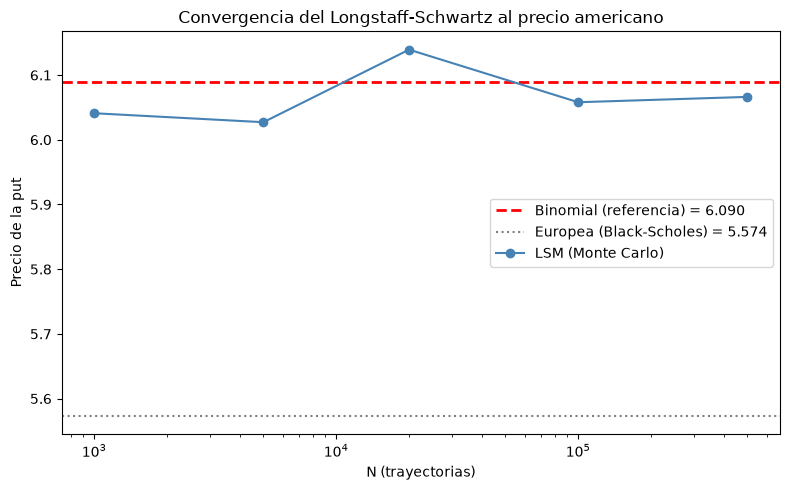

N =    1,000   LSM = 6.0410   (error 0.0490)
N =    5,000   LSM = 6.0271   (error 0.0628)
N =   20,000   LSM = 6.1393   (error 0.0493)
N =  100,000   LSM = 6.0580   (error 0.0320)
N =  500,000   LSM = 6.0662   (error 0.0237)


In [4]:
Ns = [1_000, 5_000, 20_000, 100_000, 500_000]
precios_lsm = [put_americana_lsm(S0, K, r, sigma, T, m=50, N=n, rng=rng) for n in Ns]

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(binomial, color='red', linewidth=2, linestyle='--', label=f'Binomial (referencia) = {binomial:.3f}')
ax.axhline(europea, color='gray', linewidth=1.5, linestyle=':', label=f'Europea (Black-Scholes) = {europea:.3f}')
ax.plot(Ns, precios_lsm, 'o-', color='steelblue', label='LSM (Monte Carlo)')
ax.set_xscale('log')
ax.set_xlabel('N (trayectorias)'); ax.set_ylabel('Precio de la put')
ax.set_title('Convergencia del Longstaff-Schwartz al precio americano')
ax.legend(); plt.tight_layout(); plt.show()

for n, p in zip(Ns, precios_lsm):
    print(f"N = {n:>8,}   LSM = {p:.4f}   (error {abs(p-binomial):.4f})")

---

# Sección 4 — La frontera de ejercicio y análisis

## 4.1 ¿Cuándo conviene ejercer?

El ejercicio óptimo tiene una estructura clara: para una put, existe una **frontera de ejercicio** $S^*(t)$ tal que conviene ejercer cuando el precio cae por debajo de ella. La frontera sube hacia el strike a medida que se acerca el vencimiento (cerca de $T$, casi cualquier caída ITM se ejerce). La extraemos del árbol binomial.

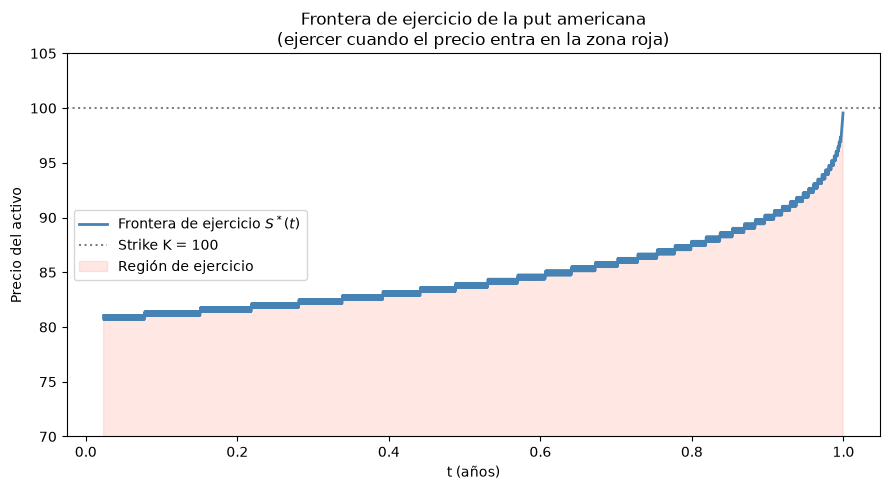

In [5]:
def frontera_ejercicio_binomial(S0, K, r, sigma, T, pasos):
    dt = T / pasos
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d); desc = np.exp(-r * dt)
    j = np.arange(pasos + 1)
    V = np.maximum(K - S0 * u**j * d**(pasos - j), 0.0)
    frontera = np.full(pasos + 1, np.nan)
    for i in range(pasos - 1, -1, -1):
        S = S0 * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
        cont = desc * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])
        ejerce = (K - S) > cont
        V = np.maximum(cont, K - S)
        if ejerce.any():
            frontera[i] = S[ejerce].max()      # mayor S en que aún se ejerce
    return np.linspace(0, T, pasos + 1), frontera

t_eje, frontera = frontera_ejercicio_binomial(S0, K, r, sigma, T, 2000)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_eje, frontera, color='steelblue', linewidth=2, label='Frontera de ejercicio $S^*(t)$')
ax.axhline(K, color='gray', linestyle=':', label=f'Strike K = {K:.0f}')
ax.fill_between(t_eje, 0, frontera, color='tomato', alpha=0.15, label='Región de ejercicio')
ax.set_xlabel('t (años)'); ax.set_ylabel('Precio del activo')
ax.set_ylim(70, 105)
ax.set_title('Frontera de ejercicio de la put americana\n(ejercer cuando el precio entra en la zona roja)')
ax.legend(); plt.tight_layout(); plt.show()

## 4.2 Cierre del módulo

**Qué hemos construido.** La valoración de opciones americanas por Monte Carlo mediante Longstaff-Schwartz, validada contra un árbol binomial, con la prima de ejercicio anticipado y la frontera de ejercicio óptimo.

**Análisis honesto.**

1. **Por qué importa el LSM.** El árbol binomial resuelve la put americana de un activo sin problema, así que aquí el Monte Carlo *no* es necesario. Pero el árbol **explota en dimensión**: con 5 activos subyacentes es inviable, mientras que el LSM apenas se resiente. El poder de Longstaff-Schwartz aparece en las americanas/bermudas **multiactivo** (cestas, opciones sobre el máximo), donde es de los pocos métodos viables. Este módulo lo valida en el caso simple para poder confiar en él en el difícil.
2. **Sesgos del método.** El LSM tiene dos sesgos que se compensan parcialmente: la regresión con datos *dentro de muestra* introduce un sesgo optimista (*foresight*), mientras que una política de ejercicio subóptima (la regresión es imperfecta) introduce un sesgo pesimista. El resultado suele quedar muy cerca del valor real, como hemos visto, pero un cálculo riguroso separaría ambos con trayectorias independientes para regresión y valoración.
3. **La elección de la base importa.** Usamos polinomios hasta grado 3; bases más ricas mejoran la estimación de la continuación pero pueden sobreajustar. Es la tensión sesgo-varianza de siempre, aquí en un problema financiero.

Con las americanas cubrimos el tipo de opción conceptualmente más difícil del proyecto, y mostramos la técnica de Monte Carlo más sofisticada: regresión incrustada en la simulación.

## Referencias

- Longstaff, F. & Schwartz, E. (2001). *Valuing American Options by Simulation*. Review of Financial Studies, 14(1).
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 8.
- Cox, J., Ross, S. & Rubinstein, M. (1979). *Option Pricing: A Simplified Approach*. J. Financial Economics, 7(3).